#  **Identificando discurso de ódio pelo LLaMa 3.1**

**Autores:** Luiz Davi da Silva Aguiar e Adonias Caetano de Oliveira

## **Installation**

In [ ]:
%%capture
import os
if "COLAB_" not in "".join(os.environ.keys()):
    !pip install unsloth
else:
    # Do this only in Colab notebooks! Otherwise use pip install unsloth
    !pip install --no-deps bitsandbytes accelerate xformers==0.0.29 peft trl triton
    !pip install --no-deps cut_cross_entropy unsloth_zoo
    !pip install sentencepiece protobuf datasets huggingface_hub hf_transfer
    !pip install --no-deps unsloth

## **Loading data**

In [ ]:
import pandas as pd
import re
import random
from string import punctuation
import numpy as np

In [ ]:
url = 'https://drive.google.com/file/d/1ur5voOHqK7JasJF6uinmQXXvlAxHJ8ni/view?usp=sharing'
file_id = url.split('/')[-2]
read_url='https://drive.google.com/uc?id=' + file_id

dataset = pd.read_csv(read_url, usecols=['text', 'hatespeech_comb'])

dataset.head()

,text,hatespeech_comb
0,Estou trabalhando num sistema onde haverá comp...,0
1,@SadBoyKevyn \nNunca penses que algo 'é o mais...,0
2,Começa pelo seu namorado @badgalerica https://...,0
3,"o discurso do socialismo pode até ser bonito, ...",0
4,RT @mayaramellon: é cheio de opinião mas não t...,0


## **Unsloth**

In [ ]:
from unsloth import FastLanguageModel
import torch
from transformers import TextStreamer
from unsloth.chat_templates import get_chat_template

🦥 Unsloth: Will patch your computer to enable 2x faster free finetuning.
🦥 Unsloth Zoo will now patch everything to make training faster!


In [ ]:
model, tokenizer = FastLanguageModel.from_pretrained(
    model_name = "unsloth/Meta-Llama-3.1-8B-Instruct-bnb-4bit",
    max_seq_length = 8192,
    load_in_4bit = True,
)

==((====))==  Unsloth 2026.8.7: Fast Llama patching. Transformers: 5.13.1.
   \\   /|    Tesla T4. Num GPUs = 1. Max memory: 14.563 GB. Platform: Linux.
O^O/ \_/ \    Torch: 2.11.0+cu128. CUDA: 7.5. CUDA Toolkit: 12.8. Triton: 3.6.0
\        /    Bfloat16 = FALSE. FA [Xformers = None. FA2 = False]
 "-____-"     Free license: http://github.com/unslothai/unsloth
Unsloth: Fast downloading is enabled - ignore downloading bars which are red colored!


Loading weights:   0%|          | 0/291 [00:00<?, ?it/s]

Unsloth: Will load unsloth/Meta-Llama-3.1-8B-Instruct-bnb-4bit as a legacy tokenizer.


In [ ]:
tokenizer = get_chat_template(
    tokenizer,
    chat_template = "llama-3.1",
    mapping = {"role" : "from", "content" : "value", "user" : "human", "assistant" : "gpt"}, # ShareGPT style
)
FastLanguageModel.for_inference(model) # Enable native 2x faster inference

LlamaForCausalLM(
  (model): LlamaModel(
    (embed_tokens): Embedding(128256, 4096, padding_idx=128004)
    (layers): ModuleList(
      (0-31): 32 x LlamaDecoderLayer(
        (self_attn): LlamaAttention(
          (q_proj): Linear4bit(in_features=4096, out_features=4096, bias=False)
          (k_proj): Linear4bit(in_features=4096, out_features=1024, bias=False)
          (v_proj): Linear4bit(in_features=4096, out_features=1024, bias=False)
          (o_proj): Linear4bit(in_features=4096, out_features=4096, bias=False)
          (rotary_emb): LlamaRotaryEmbedding()
        )
        (mlp): LlamaMLP(
          (gate_proj): Linear4bit(in_features=4096, out_features=14336, bias=False)
          (up_proj): Linear4bit(in_features=4096, out_features=14336, bias=False)
          (down_proj): Linear4bit(in_features=14336, out_features=4096, bias=False)
          (act_fn): SiLUActivation()
        )
        (input_layernorm): LlamaRMSNorm((4096,), eps=1e-05)
        (post_attention_layernorm):

In [ ]:
def get_prompt(sentenca):
  return f"""
    Você é um moderador de conteúdo. Classifique a frase assim:

    - "1" se a frase contém discurso de ódio (hate speech)
    - "0" se a frase não contém nenhum tipo de discurso de ódio (non-hate speech)


    Regras:
    - Sua saída deve ser apenas um número inteiro (0 ou 1)
    - Não inclua nenhum texto adicional na resposta

    Frase: "{sentenca}"
    """

In [ ]:
respostas_llm = {}

sentencas = dataset["text"].to_list()
targets = dataset["hatespeech_comb"].to_list()

respostas_llm["text"] = sentencas
respostas_llm["target"] = targets
respostas_llm['predicted'] = []


for sentenca in sentencas:

  prompt = get_prompt(sentenca)

  prompt_tokenizado = tokenizer([prompt], return_tensors='pt').to('cuda')
  FastLanguageModel.for_inference(model)
  input_token_len = prompt_tokenizado['input_ids'].shape[1]
  output = model.generate(
    **prompt_tokenizado,
    max_new_tokens=512,
    do_sample=False,
    temperature=0.0
)
  # Seleciona apenas os tokens gerados (ignorando os tokens do prompt)
  resposta_ids = output[0, input_token_len:]
  # Decodifica apenas a nova resposta e remove espaços em branco extras
  resposta_texto = tokenizer.decode(resposta_ids, skip_special_tokens=True).strip()

  # Extrai apenas o dígito (0 ou 1) da resposta
  match = re.search(r'\b[01]\b', resposta_texto)
  if match:
    predicao = int(match.group(0))
  else:
    predicao = -1 # Ou outro valor para indicar falha na extração

  respostas_llm['predicted'].append(predicao)

Both `max_new_tokens` (=512) and `max_length`(=131072) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)
Ignoring clean_up_tokenization_spaces=True for BPE tokenizer TokenizersBackend. The clean_up_tokenization post-processing step is designed for WordPiece tokenizers and is destructive for BPE (it strips spaces before punctuation). Set clean_up_tokenization_spaces=False to suppress this warning, or set clean_up_tokenization_spaces_for_bpe_even_though_it_will_corrupt_output=True to force cleanup anyway.
Both `max_new_tokens` (=512) and `max_length`(=131072) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)
Both `max_new_tokens` (=512) and `max_length`(=131072) seem to have been set. `max_new_tok

In [ ]:

from google.colab import files

df = pd.DataFrame(respostas_llm)
df.to_excel('respostas_llama3.xlsx', index=False)

files.download('respostas_llama3.xlsx')


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<Figure size 600x600 with 0 Axes>

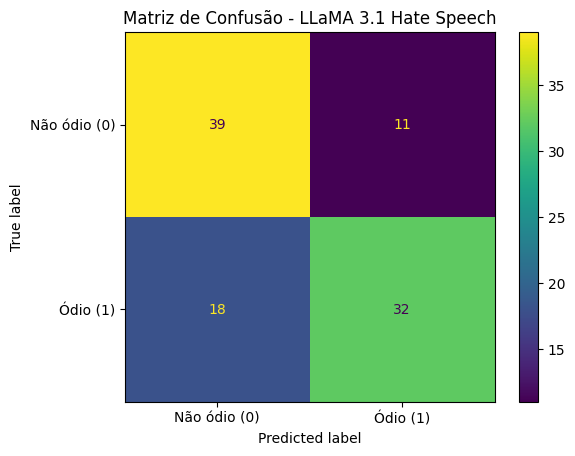

In [ ]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

# Converte para lista (caso ainda não estejam)
y_true = df["target"].tolist()
y_pred = df["predicted"].tolist()

# Gera a matriz de confusão
cm = confusion_matrix(y_true, y_pred, labels=[0,1])

# Exibe
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=["Não ódio (0)", "Ódio (1)"])
plt.figure(figsize=(6,6))
disp.plot()
plt.title("Matriz de Confusão - LLaMA 3.1 Hate Speech")
plt.show()


In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, classification_report

y_true = df["target"]
y_pred = df["predicted"]

acc = accuracy_score(y_true, y_pred)
prec = precision_score(y_true, y_pred)
rec = recall_score(y_true, y_pred)
f1 = f1_score(y_true, y_pred)

print(f"Accuracy: {acc:.4f}")
print(f"Precision: {prec:.4f}")
print(f"Recall: {rec:.4f}")
print(f"F1-score: {f1:.4f}")

NameError: name 'df' is not defined